# Fine-tuning del modelo ESM3. 
Explicación paso a paso

## Generalidades: 
En este cuaderno veremos como añadirle una capa extra al modelo ESM3, que nos permita afinarlo para que prediga directamente la Kd. En nuestra entrega previa, del desempeño del modelo zero-shot, el modelo botaba como output una probabilidad de ocurrencia de una mutación en su posición. A partir de ello, calculabamos una correlación con la Kd establecida experimentalmente para esa misma mutación. En este caso, ahora sí, buscamos, añadiendo una red neuronal por sobre el modelo ESM, que se prediga directamente la Kd, y no solamente una probabilidad.

Primero, importamos librerías necesarias. 

Nótese que en la línea `from modelo_esm3_regresion import ESM3Regressor` estamos cargando nuestra propia red MLP+atención. Esta clase contiene la red MLP que entrenaremos por encima del modelo ESM3.

In [14]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from esm.models.esm3 import ESM3
from esm.sdk.api import ESMProtein, LogitsConfig
from modelo_esm3_regresion import ESM3Regressor
import os
import time
import glob



El modelo que construimos contiene la siguiente arquitectura: 

In [ ]:
from modelo_esm3_regresion import ESM3Regressor

input_dim = 1536 #Dimensionalidad de los embeddings obtenidos por esm3-open
model = ESM3Regressor(input_dim=input_dim)

print(model)


ESM3Regressor(
  (attn): LightAttention(
    (attn_weights): Linear(in_features=1536, out_features=1, bias=True)
  )
  (mlp): Sequential(
    (0): Linear(in_features=1536, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=1, bias=True)
  )
)


Para la arquitectura inicial que hemos probado nos basamos en el paper de Dieckhaus et al. (2024), donde construyen ProteinMPNN aplicando Transfer Learning sobre ProteinMPNN con una cabeza de regresión conformada por dos bloques: LightAttention y MLP.

Nuestra arquitectura es una simplificación de lo realizado por Dieckhaus et al. (2024), pues ellos realizaron  2 convoluciones acolchadas independientes con:
- kernel de 9
- stride de 1 
- dropout de 0.25

MLP:
- Dos capas ocultas

Mantuvimos su estructura general dado su éxito para predecir la estabilidad termodinámica (ΔΔG°) y la simplificamos por cuestiones de cómputo

Continuando con el entrenamiento, lo primero es importar las librerias

A continuación definimos ubicaciones e hiperparámetros, como el tamaño de lote, las épocas, learning rate y dimensión de embedding. Recordemos que para el modelo ESM3 que estamos usando, de 1.4 B de parámetros, el tamaño del embedding es de 1536 (Hayes et al. 2024)

In [15]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
CSV_PATH = "../data/A0A1K4LHP2_CR9114_Phillips_2021_updated_target.csv"
MODEL_SAVE_PATH = "../model/esm3_regressor_kd.pt"
BATCH_SIZE = 1
EPOCHS = 10
LR = 1e-4
USE_ATTENTION = True
EMBED_DIM = 1536

Using device: cuda:0


Enseguida, definimos nuestra clase ProteinDataset, que aceptará un dataframe, para importar a partir de un índice nuestra secuencia y su valor objetivo. Esto es costumbre para cada dataset particular sobre el cual se usará Pytorch

In [16]:
# === Dataset personalizado ===
class ProteinDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return row["sequence"], torch.tensor(row["kd"], dtype=torch.float32)


Leemos nuestra base de datos, obtenemos las dos columnas de interés: secuencia y Kd. Tenemos 65 093 filas que servirán de entrenamiento. Asimismo, usaremos el 80% de las secuencias para entrenar, y el 20% como dataset de prueba

In [17]:
# === Cargar datos ===
df = pd.read_csv(CSV_PATH)[["sequence", "DMS_score"]].dropna().rename(columns={"DMS_score": "kd"})
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
print(f"Dataframe: {df}")
print("------------------------------------")
print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")

Dataframe:                                                 sequence        kd
0      QVQLVQSGAEVKKPGSSVKVSCKASGGTSSSYAISWVRQAPGQGLE...  9.484586
1      QVQLVQSGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLE...  9.430991
2      QVQLVQSGAEVKKPGSSVKVSCKASGGTSNNYAISWVRQAPGQGLE...  9.497006
3      QVQLVQSGAEVKKPGSSVKVSCKASGGTSSNYAISWVRQAPGQGLE...  9.499691
4      QVQLVQSGAEVKKPGSSVKVSCKASGGTSNNYAISWVRQAPGQGLE...  9.380737
...                                                  ...       ...
65088  QVQLVQSGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLE...  7.907556
65089  QVQLVQSGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLE...  8.326384
65090  QVQLVQSGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLE...  9.264833
65091  QVQLVQSGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLE...  8.015971
65092  QVQLVQSGAEVKKPGSSVKVSCKASGGTFSNYAISWVRQAPGQGLE...  8.848686

[65093 rows x 2 columns]
------------------------------------
Train size: 52074, Test size: 13019


Cargamos nuestros dataframes de entrenamiento y prueba en nuestra clase ProteinDataset, y vemos una muestra.

A continuación, cargamos en DatasetLoader para que se nos devuelva la información en BATCHES

In [18]:
BATCH_SIZE = 1
train_dataset = ProteinDataset(train_df)
test_dataset = ProteinDataset(test_df)
print(train_dataset)
print(f"Train dataset size: {len(train_dataset)}")
print("Train dataset sample: Sequence -------------- Kd")
print(train_dataset[2])
print("------------------------------------")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"Train loader size: {len(train_loader)}")
print("Train loader sample: Sequence -------------- Kd")
for seq, kd in train_loader:
    print(seq, "--------------", kd)
    break

Train dataset size: 52074
Train dataset sample: Sequence -------------- Kd
('QVQLVQSGAEVKKPGSSVKVSCKASGGTSSNYAISWVRQAPGQGLEWMGGISPIFGTTAYAQKFQGRVTITADKSTSTAYMELSSLRSEDTAVYFCARHGNYYYYYGMDVWGQGTTVTVSS', tensor(8.0179))
------------------------------------
Train loader size: 52074
Train loader sample: Sequence -------------- Kd
('QVQLVQSGAEVKKPGSSVKVSCKASGGTFNNYAISWVRQAPGQGLEWMGGIIPIFGTAAYAQKFQGRVTITADKFTNTAYMELSSLTSEDTAVYFCARHGNYYYYSGMDVWGQGTTVTVSS',) -------------- tensor([9.3608])


Cargamos modelo ESM3 preentrenado en modo evaluación. 

In [19]:
print(DEVICE)
esm3_model = ESM3.from_pretrained("esm3-open").to("cuda:0")
esm3_model.eval()

cuda:0


Fetching 22 files:   0%|          | 0/22 [00:00<?, ?it/s]

ESM3(
  (encoder): EncodeInputs(
    (sequence_embed): Embedding(64, 1536)
    (plddt_projection): Linear(in_features=16, out_features=1536, bias=True)
    (structure_per_res_plddt_projection): Linear(in_features=16, out_features=1536, bias=True)
    (structure_tokens_embed): Embedding(4101, 1536)
    (ss8_embed): Embedding(11, 1536)
    (sasa_embed): Embedding(19, 1536)
    (function_embed): ModuleList(
      (0-7): 8 x Embedding(260, 192, padding_idx=0)
    )
    (residue_embed): EmbeddingBag(1478, 1536, mode='sum', padding_idx=0)
  )
  (transformer): TransformerStack(
    (blocks): ModuleList(
      (0): UnifiedTransformerBlock(
        (attn): MultiHeadAttention(
          (layernorm_qkv): Sequential(
            (0): LayerNorm((1536,), eps=1e-05, elementwise_affine=True)
            (1): Linear(in_features=1536, out_features=4608, bias=False)
          )
          (out_proj): Linear(in_features=1536, out_features=1536, bias=False)
          (q_ln): LayerNorm((1536,), eps=1e-05, el

Programamos la configuración default del modelo para extraer solo los embeddings de cada posición (token) de la secuencia que solicitemos

In [20]:
logits_config = LogitsConfig(
    sequence=True,
    return_embeddings=True,
    return_hidden_states=False)

Instanciamos nuestra clase ESM3Regressor, y lo replicamos en ambas GPUs disponibles. Definimos el optimizador Adam sobre todos los parámetros entrenables y establecemos nuestra función de pérdida como el MSE.

In [21]:
regressor = ESM3Regressor(input_dim=EMBED_DIM, use_attention=USE_ATTENTION).to("cuda:0")
#regressor = nn.DataParallel(regressor, device_ids=[0,1])
optimizer = torch.optim.Adam(regressor.parameters(), lr=LR)
loss_fn = nn.MSELoss()

Creamos una función para codificar cada secuencia y obtener su embedding final completo

In [22]:
def embed_sequence(sequence):
    with torch.no_grad():
        protein = ESMProtein(sequence=sequence)
        inputs = esm3_model.encode(protein).to(DEVICE)
        output = esm3_model.logits(inputs, logits_config)
        return output.embeddings.squeeze(0).to(DEVICE)  # [seq_len, embed_dim=1536]


Nuetro entrenamiento consiste en un numero determinado de épocas, y cada época es una pasada completa por los datos de entrenamiento.

Pasos seguidos en cada época:

    1. Extraemos embeddings de cada secuencia con nuestra función embed_sequence. Este, como se verá más adelante, es un paso que nos toma demasiado tiempo.

    2. Predecimos la Kd y hallamos la pérdida en base a nuestra loss function que es MSE

    3. Reseteo de gradientes, propagación de pérdida por la red (backward()) llenando .grad en cada parámetro entrenable. Luego al aplicar step() el optimizador Adam actualiza los parámetros según los gradientes, y la tasa de aprendizaje

    4. Acumulo el valor del tensor de pérdida en total_loss

    5. Al terminar todos los batches de una época, imprimo la pérdida media

    6. Para cada muestra en test_loader recogemos su predicción y el valor real, para luego obtener el MSE y R2 de evaluación

En esta sección de entrenamiento, primero aplicamos UNA sola época, y vemos qué parte del entrenamiento toma más tiempo. Para ello, aplicamos timers tanto en la parte de la obtención del embedding de la secuencia, como en la predicción de nuestro MLP regressor, y en la sección de actualización de los pesos del regresor.

In [57]:
train_losses = []
test_losses  = []
epoch_times = []
embed_times = []
regressor_times = []
optimizer_times = []
EPOCHS=1 #Ver qué demora más en una época
for epoch in range(1, EPOCHS + 1):
    start_epoch = time.perf_counter()
    regressor.train()
    total_loss = 0
    count = 0
    
    for seq, kd in tqdm(train_loader, desc=f"Epoch {epoch} [Train]"):
        seq = seq[0]
        kd = kd.to(DEVICE)
        if count > 300:
            # Salimos del bucle de batches cuando alcancemos 500
            break
        
        try:
            # ======= Medición de tiempo para embed_sequence =======
            start_embed = time.perf_counter()
            emb = embed_sequence(seq).unsqueeze(0)  # [1, seq_len, embed_dim]
            end_embed = time.perf_counter()
            embed_time = end_embed - start_embed
            embed_times.append(embed_time)
            
            # ======= Medición de tiempo para regresor =======
            start_regressor = time.perf_counter()
            pred = regressor(emb)
            loss = loss_fn(pred, kd)
            end_regressor = time.perf_counter()
            regressor_time = end_regressor - start_regressor
            regressor_times.append(regressor_time)
            
            # ======= Medición de tiempo para optimización =======
            start_optim = time.perf_counter()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            end_optim = time.perf_counter()
            optim_time = end_optim - start_optim
            optimizer_times.append(optim_time)
            
            total_loss += loss.item()
            count += 1
            
            # ======= Reporte cada 50 batches =======
            if count % 75 == 0:
                avg_embed = sum(embed_times[-50:]) / 50
                avg_regressor = sum(regressor_times[-50:]) / 50
                avg_optim = sum(optimizer_times[-50:]) / 50
                total_batch = avg_embed + avg_regressor + avg_optim
                
                print(f"\n⏱️ Batch {count} | Tiempos (últimos 50 batches):")
                print(f"  ├─ Embed: {avg_embed:.4f}s ({avg_embed/total_batch*100:.1f}%)")
                print(f"  ├─ Regressor: {avg_regressor:.4f}s ({avg_regressor/total_batch*100:.1f}%)")
                print(f"  └─ Optimización: {avg_optim:.4f}s ({avg_optim/total_batch*100:.1f}%)")
                print(f"  Total/batch: {total_batch:.4f}s | Velocidad: {50/total_batch:.2f} batch/s")
        
        except Exception as e:
            print(f"Error en entrenamiento: {e}")
            continue
    
    # ======= Final de época =======
    avg_train_loss = total_loss / count
    print(f"\n✓ Epoch {epoch} | Train Loss promedio: {avg_train_loss:.4f}")
    train_losses.append(avg_train_loss)
    
    # === Evaluación ===
    regressor.eval()
    preds, targets = [], []
    with torch.no_grad():
        count2=0
        for seq, kd in tqdm(test_loader, desc=f"Epoch {epoch} [Eval]"):
            seq = seq[0]  
            kd = kd.to(DEVICE)
            count2+=1
            if count2 == 200:
                # Salimos del bucle de batches cuando alcancemos 500
                print("Test evaluation limit reached (200 secuencias!!).")
                break
            try:
                emb = embed_sequence(seq).unsqueeze(0)
                #print(f"Embedding shape: {emb.shape}")
                pred = regressor(emb)
                preds.append(pred.item())
                targets.append(kd.item())
                #print(f"Pred shape: {pred.shape}, kd shape: {kd.shape}")
            except Exception as e:
                print(f"Error en evaluación: {e}")
                continue

    mse = mean_squared_error(targets, preds)
    r2 = r2_score(targets, preds)
    print(f"🎯 Epoch {epoch} | Test MSE: {mse:.4f} | R²: {r2:.4f}")
    test_losses.append(mse)

    end_epoch = time.perf_counter()
    duration = end_epoch - start_epoch
    epoch_times.append(duration)
    
    # ======= Reporte de tiempos de época =======
    avg_embed_epoch = sum(embed_times[-count:]) / count if count > 0 else 0
    avg_regressor_epoch = sum(regressor_times[-count:]) / count if count > 0 else 0
    avg_optim_epoch = sum(optimizer_times[-count:]) / count if count > 0 else 0
    
    print(f"\n📊 RESUMEN TIEMPOS Epoch {epoch}")
    print(f"  ├─ Embed: {avg_embed_epoch:.4f}s/batch ({len(embed_times)} batches)")
    print(f"  ├─ Regressor: {avg_regressor_epoch:.4f}s/batch")
    print(f"  ├─ Optimización: {avg_optim_epoch:.4f}s/batch")
    print(f"  └─ Total época: {duration:.1f}s ({count/duration:.2f} batch/s)")
    print(f"⏱️ Epoch {epoch} duración: {duration:.1f}s")

Epoch 1 [Train]:   0%|          | 77/52074 [00:02<32:02, 27.05it/s]


⏱️ Batch 75 | Tiempos (últimos 50 batches):
  ├─ Embed: 0.0361s (95.1%)
  ├─ Regressor: 0.0005s (1.3%)
  └─ Optimización: 0.0014s (3.7%)
  Total/batch: 0.0380s | Velocidad: 1315.51 batch/s


Epoch 1 [Train]:   0%|          | 152/52074 [00:06<41:18, 20.95it/s]


⏱️ Batch 150 | Tiempos (últimos 50 batches):
  ├─ Embed: 0.0483s (95.9%)
  ├─ Regressor: 0.0005s (1.0%)
  └─ Optimización: 0.0015s (3.0%)
  Total/batch: 0.0504s | Velocidad: 992.07 batch/s


Epoch 1 [Train]:   0%|          | 230/52074 [00:10<34:36, 24.97it/s]  


⏱️ Batch 225 | Tiempos (últimos 50 batches):
  ├─ Embed: 0.0576s (96.3%)
  ├─ Regressor: 0.0006s (1.0%)
  └─ Optimización: 0.0016s (2.7%)
  Total/batch: 0.0598s | Velocidad: 836.80 batch/s


Epoch 1 [Train]:   1%|          | 301/52074 [00:13<38:49, 22.22it/s]



⏱️ Batch 300 | Tiempos (últimos 50 batches):
  ├─ Embed: 0.0348s (94.6%)
  ├─ Regressor: 0.0005s (1.3%)
  └─ Optimización: 0.0015s (4.1%)
  Total/batch: 0.0368s | Velocidad: 1360.29 batch/s

✓ Epoch 1 | Train Loss promedio: 3.1520


Epoch 1 [Eval]:   2%|▏         | 199/13019 [00:05<05:36, 38.05it/s]

Test evaluation limit reached (200 secuencias!!).
🎯 Epoch 1 | Test MSE: 1.8461 | R²: -3.1275

📊 RESUMEN TIEMPOS Epoch 1
  ├─ Embed: 0.0422s/batch (301 batches)
  ├─ Regressor: 0.0005s/batch
  ├─ Optimización: 0.0015s/batch
  └─ Total época: 18.8s (16.03 batch/s)
⏱️ Epoch 1 duración: 18.8s


Truncamos la salida, y vemos que, para cada secuencia, se toma el 90% del tiempo solamente en obtener su embedding. Pero nosotros ya tenemos calculado los embeddings de cada secuencia, gracias a nuestro trabajo de preprocesamiento. Así que, a continuación, simplemente importamos el archivo con los embeddings y los cargamos a un diccionario

In [ ]:
# === Cargar embeddings desde el archivo concatenado ===
EMBEDDINGS_DIR = "/media/nova/datos/proj_esm3_proof/250610_esm3/results/embeddings_token_final"
CONCATENATED_PATH = os.path.join(EMBEDDINGS_DIR, "concatenated_embeddings_final.pt")
EMBEDDINGS_DICT = {}

print("Cargando embeddings precalculados...")
start_load = time.time()

if os.path.exists(CONCATENATED_PATH):
    try:
        EMBEDDINGS_DICT = torch.load(CONCATENATED_PATH, map_location='cpu')
        print(f"✓ Embeddings cargados desde archivo concatenado: {len(EMBEDDINGS_DICT)} secuencias")

    except Exception as e:
        print(f"Error al cargar el archivo concatenado: {e}")
else:
    print(f"Error: Concatenated embeddings file not found at {CONCATENATED_PATH}")
print(f"Tiempo de carga: {time.time() - start_load:.2f} segundos")
print(f"Memoria usada: {len(EMBEDDINGS_DICT) * EMBED_DIM * 4 / 1e9:.2f} GB (aproximado)")

Cargando embeddings precalculados...
✓ Embeddings cargados desde archivo concatenado: 65093 secuencias
Tiempo de carga: 19.51 segundos
Memoria usada: 0.40 GB (aproximado)


In [ ]:
#count = 0
#for seq_id, emb in EMBEDDINGS_DICT.items():
#    count += 1
#    EMBEDDINGS_DICT[seq_id] = emb.to("cuda:0")
#    print(count)
    #print(f"✓ Embeddings cargados y movidos a {DEVICE}")
#print(count)

In [ ]:
print(f"✓ Embeddings cargados: {len(EMBEDDINGS_DICT)} secuencias")
for idx, (key, value) in enumerate(EMBEDDINGS_DICT.items()):
    if idx < 5:  # Mostrar solo los primeros 5 embeddings
        print(f"{key}: {value.shape}")
    else:
        break
problem_sequence = 'QVQLVQSGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLEWMGGIIPIFGSTAYAQKFQGRVTITADKSTNTAYMELSSLRSEDTAVYYCARHGNYYYYYGMDVWGQGTTVTVSS'
print(problem_sequence in EMBEDDINGS_DICT)  # Debería ser True

✓ Embeddings cargados: 65093 secuencias
QVQLVQSGAEVKKPGSSVKVSCKASGGTSSSYAISWVRQAPGQGLEWMGGISPIFGSTNYAQKFQGRVTITADISTSTAYMELSSLTSEDTAVYYCARHGNYYYYSGMDVWGQGTTVTVSS: torch.Size([123, 1536])
QVQLVQSGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLEWMGGISPIFGSTAYAQKFQGRVTISADISTNTAYMELNSLRSEDTAVYFCARHGNYYYYSGMDVWGQGTTVTVSS: torch.Size([123, 1536])
QVQLVQSGAEVKKPGSSVKVSCKASGGTSNNYAISWVRQAPGQGLEWMGGISPIFGSTNYAQKFQGRVTITADISTNTAYMELNSLTSEDTAVYFCARHGNYYYYSGMDVWGQGTTVTVSS: torch.Size([123, 1536])
QVQLVQSGAEVKKPGSSVKVSCKASGGTSSNYAISWVRQAPGQGLEWMGGISPIFGSTAYAQKFQGRVTISADISSSTAYMELNSLTSEDTAVYFCARHGNYYYYYGMDVWGQGTTVTVSS: torch.Size([123, 1536])
QVQLVQSGAEVKKPGSSVKVSCKASGGTSNNYAISWVRQAPGQGLEWMGGISPIFGSAAYAQKFQGRVTITADISTSTAYMELSSLTSEDTAVYFCARHGNYYYYSGMDVWGQGTTVTVSS: torch.Size([123, 1536])
True


Nuevo entrenamiento, pero esta vez como usaremos los embeddings precalculados, aprovechamos y reestablecemos el tamaño del batch size a 32, porque esta vez se irá mucho más rápido.

In [ ]:
BATCH_SIZE=32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"Train loader size: {len(train_loader)}")
print("Train loader sample: Sequence -------------- Kd")
for seq, kd in train_loader:
    print(seq, "--------------", kd)
    break

Train loader size: 1628
Train loader sample: Sequence -------------- Kd
('QVQLVQSGAEVKKPGSSVKVSCKASGGTSSSYAISWVRQAPGQGLEWMGGISPIFGSTAYAQKFQGRVTITADKSSNTAYMELNSLTSEDTAVYYCARHGNYYYYYGMDVWGQGTTVTVSS', 'QVQLVQSGAEVKKPGSSVKVSCKASGGTSNNYAISWVRQAPGQGLEWMGGIIPIFGTTAYAQKFQGRVTITADIFSSTAYMELNSLTSEDTAVYFCARHGNYYYYSGMDVWGQGTTVTVSS', 'QVQLVQSGAEVKKPGSSVKVSCKASGGTSNNYAISWVRQAPGQGLEWMGGIIPIFGSANYAQKFQGRVTISADISSSTAYMELSSLRSEDTAVYYCARHGNYYYYSGMDVWGQGTTVTVSS', 'QVQLVQSGAEVKKPGSSVKVSCKASGGTSSNYAISWVRQAPGQGLEWMGGISPIFGTANYAQKFQGRVTISADIFSSTAYMELSSLTSEDTAVYYCARHGNYYYYSGMDVWGQGTTVTVSS', 'QVQLVQSGAEVKKPGSSVKVSCKASGGTSNSYAISWVRQAPGQGLEWMGGISPIFGTANYAQKFQGRVTITADKSSSTAYMELSSLRSEDTAVYFCARHGNYYYYYGMDVWGQGTTVTVSS', 'QVQLVQSGAEVKKPGSSVKVSCKASGGTSNNYAISWVRQAPGQGLEWMGGISPIFGTAAYAQKFQGRVTITADISTSTAYMELNSLTSEDTAVYFCARHGNYYYYYGMDVWGQGTTVTVSS', 'QVQLVQSGAEVKKPGSSVKVSCKASGGTSSSYAISWVRQAPGQGLEWMGGISPIFGTANYAQKFQGRVTISADKFSSTAYMELNSLTSEDTAVYFCARHGNYYYYYGMDVWGQGTTVTVSS', 'QVQLVQSGAEVKKPGSSVKVSCKASGGTSSSYAISWVRQAPGQGLEWMGGI

Instanciamos un nuevo Regressor

In [ ]:
regressor = ESM3Regressor(input_dim=EMBED_DIM, use_attention=USE_ATTENTION).to("cuda:0")
#regressor = nn.DataParallel(regressor, device_ids=[0,1])
optimizer = torch.optim.Adam(regressor.parameters(), lr=LR)
loss_fn = nn.MSELoss()

Actualizamos nuestra función de recuperación de embeddings para usar directamente el diccionario con los embeddings precalculados

In [ ]:
def embed_batch_from_cache(seq_ids):
    """
    Process a batch of sequences. 
    """
    embeddings = [EMBEDDINGS_DICT[seq_id] for seq_id in seq_ids]
    return torch.stack(embeddings).to(DEVICE)  # Aseguramos que las dimensiones sean correctas

Resumen de parametros entrenables de nuestro regresor

In [ ]:
for name, param in regressor.named_parameters():
    if param.requires_grad:
        print(f"{name:30} | {param.numel():>8} parámetros")


attn.attn_weights.weight       |     1536 parámetros
attn.attn_weights.bias         |        1 parámetros
mlp.0.weight                   |   393216 parámetros
mlp.0.bias                     |      256 parámetros
mlp.3.weight                   |      256 parámetros
mlp.3.bias                     |        1 parámetros


Ahora sí, entrenamos nuevamente, y vemos que el porcentaje de tiempo usado en obtener los embeddings, y también su valor absoluto, se reduce dramáticamente, incrementando la rapidez del entrenamiento de nuestra capa de regresión

_Nota: El entrenamiento se realizó con un script aparte para poder dejarlo corriendo en segundo plano, dado que iba a tomar más tiempo del que podíamos monitorearlo constantemente_

In [ ]:
train_losses = []
test_losses  = []
epoch_times = []
embed_times = []
r2_scores = []
regressor_times = []
optimizer_times = []
EPOCHS=500 #Ver qué demora más en una época
for epoch in range(1, EPOCHS + 1):
    start_epoch = time.perf_counter()
    regressor.train()
    total_loss = 0
    count = 0
    #batch_counter = 0  # Contador de batches
    
    for seq, kd in tqdm(train_loader, desc=f"Epoch {epoch} [Train]"):
        seq = list(seq)  # Convierte el batch de secuencias a lista
        kd = kd.to(DEVICE)
        #print(f"Batch size: {len(seq)}")
        #batch_counter += 1
        #if batch_counter > 10:
            # Salimos del bucle de batches cuando alcancemos 500
        #    break
        try:
            # ======= Medición de tiempo para embed_sequence =======
            start_embed = time.perf_counter()
            emb = embed_batch_from_cache(seq)  # [1, seq_len, embed_dim]
            #print(f"Embedding shape: {emb.shape}")
            #print(emb.shape)
            end_embed = time.perf_counter()
            embed_time = end_embed - start_embed
            embed_times.append(embed_time)
            
            # ======= Medición de tiempo para regresor =======
            start_regressor = time.perf_counter()
            pred = regressor(emb)  # [1, embed_dim]
            #print(f"Pred shape: {pred.shape}, kd shape: {kd.shape}")
            loss = loss_fn(pred, kd)
            #print(f"Loss: {loss.item()}")
            end_regressor = time.perf_counter()
            regressor_time = end_regressor - start_regressor
            regressor_times.append(regressor_time)
            #print(f"Regressor time: {regressor_time:.4f}s")
            
            # ======= Medición de tiempo para optimización =======
            start_optim = time.perf_counter()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            end_optim = time.perf_counter()
            optim_time = end_optim - start_optim
            optimizer_times.append(optim_time)
            
            total_loss += loss.item()
            count += 1
            
            # ======= Reporte a los 500 batches =======
            if count == 500:
                avg_embed = sum(embed_times[-50:]) / 50
                avg_regressor = sum(regressor_times[-50:]) / 50
                avg_optim = sum(optimizer_times[-50:]) / 50
                total_batch = avg_embed + avg_regressor + avg_optim
                
                print(f"\n⏱️ Batch {count} | Tiempos (últimos 50 batches):")
                print(f"  ├─ Embed: {avg_embed:.4f}s ({avg_embed/total_batch*100:.1f}%)")
                print(f"  ├─ Regressor: {avg_regressor:.4f}s ({avg_regressor/total_batch*100:.1f}%)")
                print(f"  └─ Optimización: {avg_optim:.4f}s ({avg_optim/total_batch*100:.1f}%)")
                print(f"  Total/batch: {total_batch:.4f}s | Velocidad: {50/total_batch:.2f} batch/s")
        
        except Exception as e:
            print(f"Error en entrenamiento: {e}")
            continue
    
    # ======= Final de época =======
    avg_train_loss = total_loss / count
    print(f"\n✓ Epoch {epoch} | Train Loss promedio: {avg_train_loss:.4f}")
    train_losses.append(avg_train_loss)
    
    # === Evaluación ===
    regressor.eval()
    preds, targets = [], []
    with torch.no_grad():
        #count3 = 0
        for seq, kd in tqdm(test_loader, desc=f"Epoch {epoch} [Eval]"):
            #count3 += 1
            #if count3 > 100:
                # Salimos del bucle de batches cuando alcancemos 500
            #    break
            seq = list(seq)            
            kd = kd.to(DEVICE)
            try:
                emb = embed_batch_from_cache(seq)
                #print(f"Embedding shape: {emb.shape}")
                pred = regressor(emb)  # [1, embed_dim]
                #print(f"Pred shape: {pred.shape}, kd shape: {kd.shape}")
                preds.extend(pred.cpu().tolist())
                targets.extend(kd.cpu().tolist())
                #print(f"Pred shape: {pred.shape}, kd shape: {kd.shape}")
            except Exception as e:
                print(f"Error en evaluación: {e}")
                continue

    mse = mean_squared_error(targets, preds)
    print(f"Preds: {len(preds)}, Targets: {len(targets)}")
    print(f"Preds: {preds[:5]}, Targets: {targets[:5]}")
    print(mse)
    r2 = r2_score(targets, preds)
    print(r2)
    print(f"🎯 Epoch {epoch} | Test MSE: {mse:.4f} | R²: {r2:.4f}")
    test_losses.append(mse)
    r2_scores.append(r2)  # <--- AÑADE ESTA LÍNEA

    end_epoch = time.perf_counter()
    duration = end_epoch - start_epoch
    epoch_times.append(duration)
    
    # ======= Reporte de tiempos de época =======
    avg_embed_epoch = sum(embed_times[-count:]) / count if count > 0 else 0
    avg_regressor_epoch = sum(regressor_times[-count:]) / count if count > 0 else 0
    avg_optim_epoch = sum(optimizer_times[-count:]) / count if count > 0 else 0
    if epoch <5:
        print(f"\n📊 RESUMEN TIEMPOS Epoch {epoch}")
        print(f"  ├─ Embed: {avg_embed_epoch:.4f}s/batch ({len(embed_times)} batches)")
        print(f"  ├─ Regressor: {avg_regressor_epoch:.4f}s/batch")
        print(f"  ├─ Optimización: {avg_optim_epoch:.4f}s/batch")
        print(f"  └─ Total época: {duration:.1f}s ({count/duration:.2f} batch/s)")
        print(f"⏱️ Epoch {epoch} duración: {duration:.1f}s")

In [ ]:
# === Encontrar el mejor modelo ===
best_epoch = r2_scores.index(max(r2_scores)) + 1  # +1 porque las épocas empiezan en 1
best_r2 = max(r2_scores)
best_mse = test_losses[best_epoch - 1]  # -1 porque las listas empiezan en 0

print(f"🌟 Mejor modelo: Época {best_epoch} con R² = {best_r2:.4f} y MSE = {best_mse:.4f}")

# === Guardar métricas y modelo ===
torch.save({
    'train_losses': train_losses,
    'test_losses': test_losses,
    'r2_scores': r2_scores,
    'epoch_times': epoch_times,
    'best_epoch': best_epoch,
    'best_r2': best_r2,
    'best_mse': best_mse,
    'model_state': regressor.state_dict(),
    'hyperparameters': {
        'batch_size': BATCH_SIZE,
        'epochs': EPOCHS,
        'learning_rate': LR,
        'embed_dim': EMBED_DIM,
        'use_attention': USE_ATTENTION
    }
}, "../model/training_metrics.pt")

# === Guardar solo el modelo ===
torch.save(regressor.state_dict(), MODEL_SAVE_PATH)

print(f"✅ Modelo final guardado en {MODEL_SAVE_PATH}")
print(f"✅ Métricas de entrenamiento guardadas en ../model/training_metrics.pt")
print(f"🌟 Mejor modelo: Época {best_epoch} con R² = {best_r2:.4f}")

# Graficamos la evolución de las pérdidas en entrenamiento y test

Primero cargamos los datos guardados por el entrenamiento en segundo plano de 200 epocas

In [43]:
import torch
import matplotlib.pyplot as plt

metrics_path = "../model/training_metrics.pt"

print("Cargando métricas guardadas...")
try:
    metrics = torch.load(metrics_path)
    train_losses = metrics['train_losses']
    test_losses = metrics['test_losses']
    r2_scores = metrics['r2_scores']
    epoch_times = metrics['epoch_times']
    best_epoch = metrics['best_epoch']
    best_r2 = metrics['best_r2']
    best_mse = metrics['best_mse']
    hyperparameters = metrics['hyperparameters']
    EPOCHS = len(train_losses)
    print(f"✓ Métricas cargadas desde {metrics_path}")
    print(f"📊 Datos cargados:")
    print(f"  ├─ Épocas entrenadas: {EPOCHS}")
    print(f"  ├─ Mejor época: {best_epoch}")
    print(f"  ├─ Mejor R²: {best_r2:.4f}")
    print(f"  ├─ Mejor MSE: {best_mse:.4f}")
    print(f"  └─ Hiperparámetros: {hyperparameters}")
except FileNotFoundError:
    print(f"Error: El archivo de métricas no se encontró en {metrics_path}")
    train_losses = []
    test_losses = []
    r2_scores = []
    epoch_times = []
    best_epoch = None
    best_r2 = None
    best_mse = None
    hyperparameters = {}


Cargando métricas guardadas...
✓ Métricas cargadas desde ../model/training_metrics.pt
📊 Datos cargados:
  ├─ Épocas entrenadas: 200
  ├─ Mejor época: 180
  ├─ Mejor R²: 0.7792
  ├─ Mejor MSE: 0.0914
  └─ Hiperparámetros: {'batch_size': 32, 'epochs': 200, 'learning_rate': 0.0001, 'embed_dim': 1536, 'use_attention': True}


Visualizamos la curva de aprendizaje y la evolución del R²

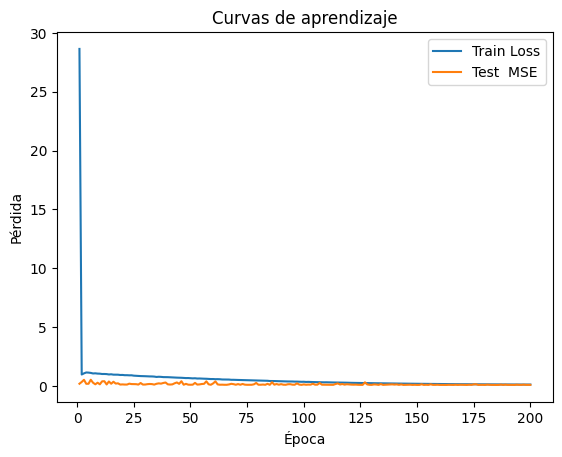

In [44]:
import matplotlib.pyplot as plt

epochs = list(range(1, EPOCHS+1))
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, test_losses,  label='Test  MSE')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.title('Curvas de aprendizaje')
plt.show()


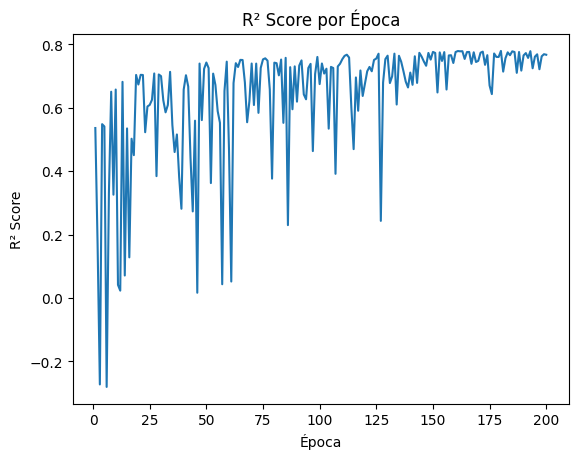

In [53]:
r2_scores
plt.title('R² Score por Época')
plt.xlabel('Época')
plt.ylabel('R² Score')
plt.plot(epochs, r2_scores, label='R² Score')

A continuación, graficamos en conjunto la evolución del loss, el MSE y el R^2 

El mejor MSE de 0.0914 equivale a aproximadamente 0.3 RMSE

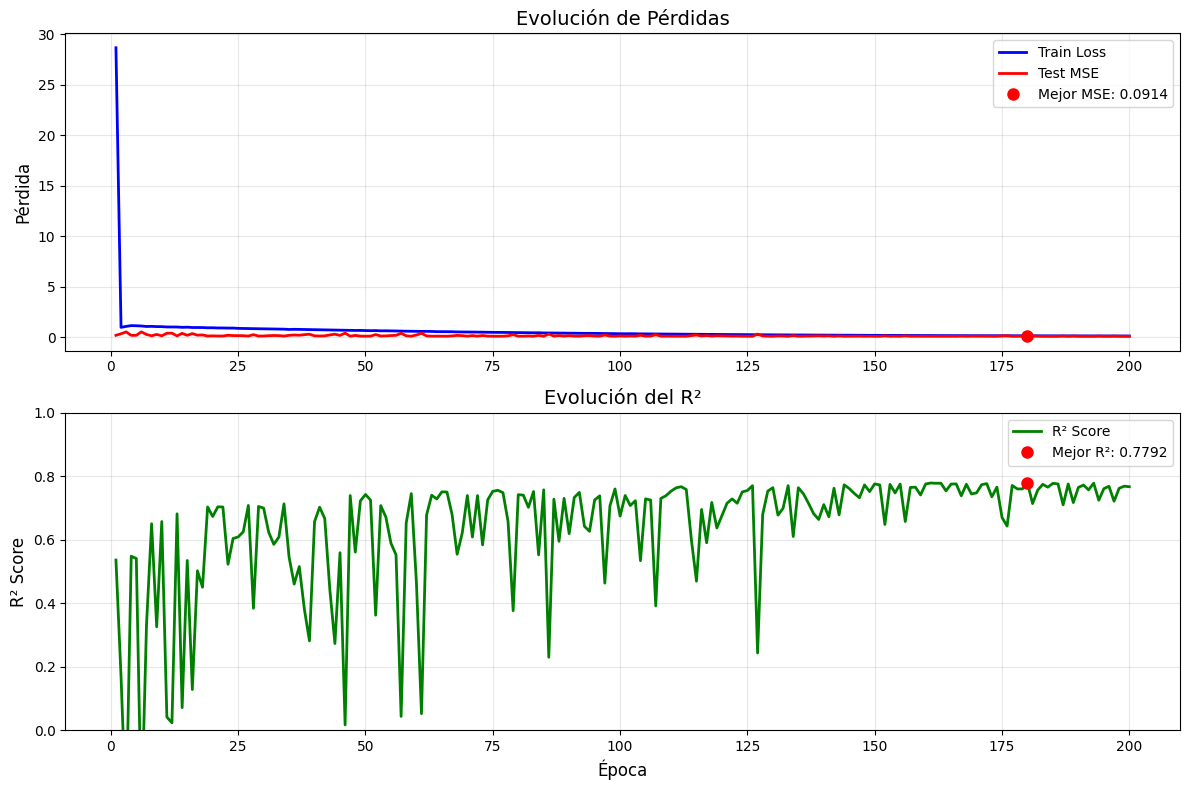

In [46]:
# === Graficar resultados ===
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
epochs = list(range(1, EPOCHS+1))
plt.plot(epochs, train_losses, 'b-', label='Train Loss', linewidth=2)
plt.plot(epochs, test_losses, 'r-', label='Test MSE', linewidth=2)
plt.plot(best_epoch, best_mse, 'ro', markersize=8, label=f'Mejor MSE: {best_mse:.4f}')
plt.title('Evolución de Pérdidas', fontsize=14)
plt.ylabel('Pérdida', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(epochs, r2_scores, 'g-', label='R² Score', linewidth=2)
plt.plot(best_epoch, best_r2, 'ro', markersize=8, label=f'Mejor R²: {best_r2:.4f}')
plt.title('Evolución del R²', fontsize=14)
plt.xlabel('Época', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

Para comparar entonces qué tal lo hace nuestro modelo si lo comparamos con una predicción aleatoria dada la distribución de nuestra data (su media y desviación estándar)

El error cuadrático medio es:
 $$
 RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^n (\hat{y}_i - y_i)^2}
 $$

La desviación estandar:
$$
\sigma = \sqrt{\frac{1}{n} \sum_{i=1}^n (y_i - \bar{y})^2}
$$

Podríamos decir que una elección al azar (de la data naturalmente obtenida) debería caer en el rango de:
$$
 \mu - \sigma < \mu < \mu + \sigma
 $$

Además, como R² = 1 – (RMSE/σ)², lograr RMSE < σ equivale a obtener R²>0 (Skeptric), se podría decir que un pronostico es eficiente si el RMSE es menor a la σ (Gelfan et al. 2018).


In [52]:
import math
print(f"σ:\t{df['kd'].std():.4f}")
print(f"RMSE:\t{math.sqrt(best_mse):.4f}")

σ:	0.6394
RMSE:	0.3024


Nuestra predicción entonces se comporta mejor que una elección al azar natural que toma en cuenta unicamente la media

# Siguientes pasos

- Evaluar más Épocas
- Modificar la earquitectura
- Normalizar el Kd para que no se dé ese primer cambio abrupto en el train loss

# Referencias

- Dieckhaus, H., Brocidiacono, M., Randolph, N. Z., & Kuhlman, B. (2024). Transfer learning to leverage larger datasets for improved prediction of protein stability changes. Proceedings of the National Academy of Sciences. https://doi.org/10.1073/pnas.2314853121
- Gelfan, A., Moreydo, V., Motovilov, Y., & Solomatine, D. P. (2018). Long-term ensemble forecast of snowmelt inflow into the Cheboksary Reservoir under two different weather scenarios. Hydrology and Earth System Sciences, 22, 2073–2089. https://doi.org/10.5194/hess-22-2073-2018
- Hayes, T., Rao, R., Akin, H., Sofroniew, N. J., Oktay, D., Lin, Z., Verkuil, R., Tran, V. Q., Deaton, J., Wiggert, M., Badkundri, R., Shafkat, I., Gong, J., Derry, A., Molina, R. S., Thomas, N., Khan, Y., Mishra, C., Kim, C., Bartie, L. J., Nemeth, M., Hsu, P. D., Sercu, T., Candido, S., & Rives, A. (2024). Simulating 500 million years of evolution with a language model. Proceedings of the National Academy of Sciences.
- Skeptric (2019). _Root Mean Squared Error (RMSE)_. Skeptric. https://skeptric.com/constant-models/#:~:text=Root%20Mean%20Squared%20Error%20,RMSE%20is%20the%20standard%20deviation
